# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4113s 24us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

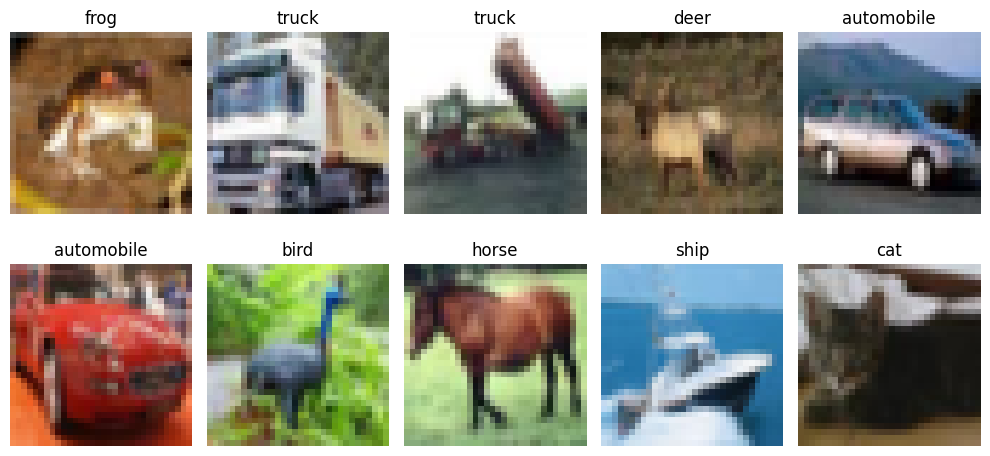

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2662 - loss: 2.0112 - val_accuracy: 0.3378 - val_loss: 1.8392
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3096 - loss: 1.8837 - val_accuracy: 0.3508 - val_loss: 1.8043
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3273 - loss: 1.8342 - val_accuracy: 0.3822 - val_loss: 1.7488
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3450 - loss: 1.7941 - val_accuracy: 0.3870 - val_loss: 1.7292
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3544 - loss: 1.7748 - val_accuracy: 0.3888 - val_loss: 1.7310
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3580 - loss: 1.7572 - val_accuracy: 0.4030 - val_loss: 1.6919
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3671 - loss: 1.7416 - val_accuracy: 0.4160 - val_loss: 1.6891
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3708 - loss: 1.7287 - val_accuracy: 0.

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4237 - loss: 1.6454
ANN Test Accuracy: 0.4237000048160553


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4621 - loss: 1.5044 - val_accuracy: 0.4616 - val_loss: 1.6402
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6017 - loss: 1.1395 - val_accuracy: 0.5632 - val_loss: 1.2568
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6649 - loss: 0.9635 - val_accuracy: 0.6316 - val_loss: 1.0560
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7045 - loss: 0.8452 - val_accuracy: 0.6672 - val_loss: 0.9797
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7381 - loss: 0.7487 - val_accuracy: 0.6850 - val_loss: 0.9176
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7656 - loss: 0.6651 - val_accuracy: 0.6886 - val_loss: 0.9094
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7884 - loss: 0.5952 - val_accuracy: 0.5590 - val_loss: 1.6847
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8070 - loss: 0.5423 - val_accuracy: 

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6890 - loss: 1.0491
CNN Test Accuracy: 0.6890000104904175


## 📈 Compare Learning Curves

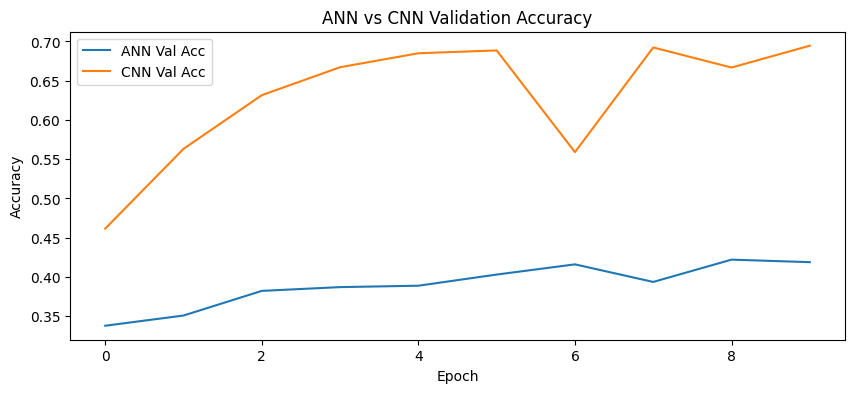

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [13]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4237
1,CNN,0.6890


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

# Student Task 1: Enhanced ANN

## Objective

This model improves the original ANN by adding more Dense layers, increasing the training epochs to 20, and using EarlyStopping to reduce overfitting.

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

enhanced_ann = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    # Added Dense Layer
    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

enhanced_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

enhanced_ann_history = enhanced_ann.fit(
    x_train_flat,
    y_train,
    validation_split=0.2,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

enhanced_ann_loss, enhanced_ann_accuracy = enhanced_ann.evaluate(
    x_test_flat,
    y_test,
    verbose=0
)

print(f"Enhanced ANN Accuracy: {enhanced_ann_accuracy:.4f}")
print(f"Enhanced ANN Loss: {enhanced_ann_loss:.4f}")

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2551 - loss: 2.0083 - val_accuracy: 0.3191 - val_loss: 1.8698
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3106 - loss: 1.8798 - val_accuracy: 0.3536 - val_loss: 1.8222
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3316 - loss: 1.8301 - val_accuracy: 0.3687 - val_loss: 1.7855
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3462 - loss: 1.7957 - val_accuracy: 0.3815 - val_loss: 1.7591
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3613 - loss: 1.7606 - val_accuracy: 0.3926 - val_loss: 1.7318
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3680 - loss: 1.7448 - val_accuracy: 0.3984 - val_loss: 1.7278
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3739 - loss: 1.7274 - val_accuracy: 0.3986 - val_loss: 1.7072
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3812 - loss: 1.7099 - 

## Observation

The enhanced ANN uses an additional Dense layer to learn more complex features. EarlyStopping helps stop training when the model no longer improves, reducing the risk of overfitting.

# Student Task 2: Enhanced CNN

## Objective

The CNN is trained for 20 epochs with EarlyStopping to improve performance and reduce overfitting.

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

# EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# Same CNN architecture
enhanced_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

enhanced_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

enhanced_cnn_history = enhanced_cnn.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

enhanced_cnn_loss, enhanced_cnn_accuracy = enhanced_cnn.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

print(f"Enhanced CNN Accuracy : {enhanced_cnn_accuracy:.4f}")
print(f"Enhanced CNN Loss     : {enhanced_cnn_loss:.4f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4766 - loss: 1.4717 - val_accuracy: 0.5272 - val_loss: 1.3372
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6120 - loss: 1.1097 - val_accuracy: 0.6002 - val_loss: 1.1376
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6764 - loss: 0.9333 - val_accuracy: 0.6760 - val_loss: 0.9464
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7187 - loss: 0.8100 - val_accuracy: 0.6346 - val_loss: 1.1488
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7481 - loss: 0.7200 - val_accuracy: 0.6270 - val_loss: 1.2492
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7766 - loss: 0.6373 - val_accuracy: 0.7268 - val_loss: 0.8443
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7995 - loss: 0.5711 - val_accuracy: 0.7060 - val_loss: 0.9429
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8175 - loss: 0.5188 - val_accuracy: 

## Observation

The enhanced CNN uses the same architecture as the original model but trains for more epochs with EarlyStopping. This helps improve learning while preventing unnecessary training.

# Student Task 3: Enhanced CNN with Data Augmentation

## Objective

This model uses data augmentation along with EarlyStopping and 20 training epochs to improve generalization and reduce overfitting.

In [19]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Data Augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Augmented CNN
augmented_cnn = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

augmented_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

augmented_cnn_history = augmented_cnn.fit(
    x_train_norm,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

augmented_cnn_loss, augmented_cnn_accuracy = augmented_cnn.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

print(f"Augmented CNN Accuracy : {augmented_cnn_accuracy:.4f}")
print(f"Augmented CNN Loss     : {augmented_cnn_loss:.4f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4103 - loss: 1.6465 - val_accuracy: 0.4682 - val_loss: 1.4663
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5053 - loss: 1.3953 - val_accuracy: 0.5570 - val_loss: 1.2980
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5467 - loss: 1.2807 - val_accuracy: 0.5796 - val_loss: 1.2394
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5796 - loss: 1.1971 - val_accuracy: 0.6196 - val_loss: 1.1349
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6000 - loss: 1.1415 - val_accuracy: 0.5794 - val_loss: 1.2991
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6194 - loss: 1.0945 - val_accuracy: 0.6528 - val_loss: 0.9872
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6319 - loss: 1.0601 - val_accuracy: 0.6422 - val_loss: 1.0517
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6453 - loss: 1.0199 - val_acc

## Observation

Data augmentation creates slightly different versions of the training images, helping the model generalize better. Combined with EarlyStopping, it reduces overfitting and can improve test performance.

# Student Task 4: Performance Comparison of All Models

## Objective

Compare the performance of the original and enhanced models using their test accuracy.

In [28]:
comparison_df = pd.DataFrame({
    "Model": [
        "Original ANN",
        "Enhanced ANN",
        "Original CNN",
        "Enhanced CNN",
        "Augmented CNN"
    ],
    "Test Accuracy": [
        ann_test_acc,
        enhanced_ann_accuracy,
        cnn_test_acc,
        enhanced_cnn_accuracy,
        augmented_cnn_accuracy
    ]
})

comparison_df.reset_index(drop=True, inplace=True)

comparison_df

,Model,Test Accuracy
0,Original ANN,0.4237
1,Enhanced ANN,0.4344
2,Original CNN,0.6890
3,Enhanced CNN,0.7085
4,Augmented CNN,0.7206


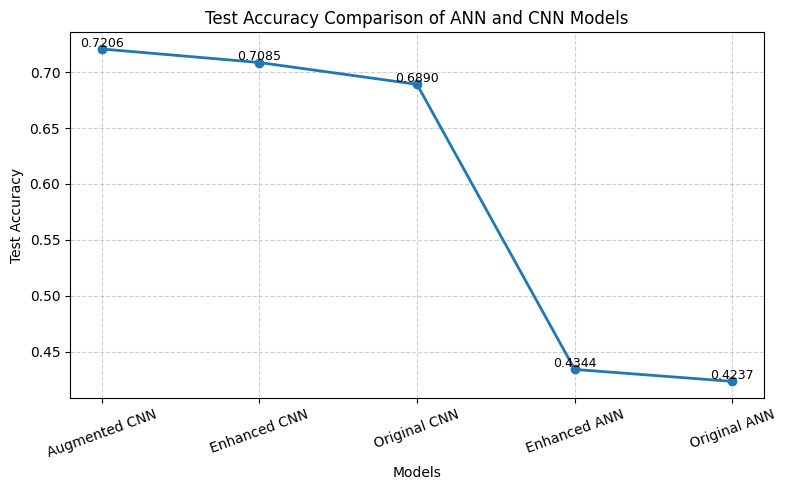

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    comparison_df["Model"],
    comparison_df["Test Accuracy"],
    marker='o',
    linewidth=2
)

plt.title("Test Accuracy Comparison of ANN and CNN Models")
plt.xlabel("Models")
plt.ylabel("Test Accuracy")

plt.grid(True, linestyle='--', alpha=0.6)

plt.xticks(rotation=20)

for i, acc in enumerate(comparison_df["Test Accuracy"]):
    plt.text(i, acc + 0.002, f"{acc:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Observation

The comparison shows how the different improvements affect model performance. CNN-based models generally perform better than ANN because they learn image features more effectively. Data augmentation further improves the model's ability to generalize.

# Validation Accuracy Comparison

## Objective

Compare the validation accuracy of all enhanced models during training.

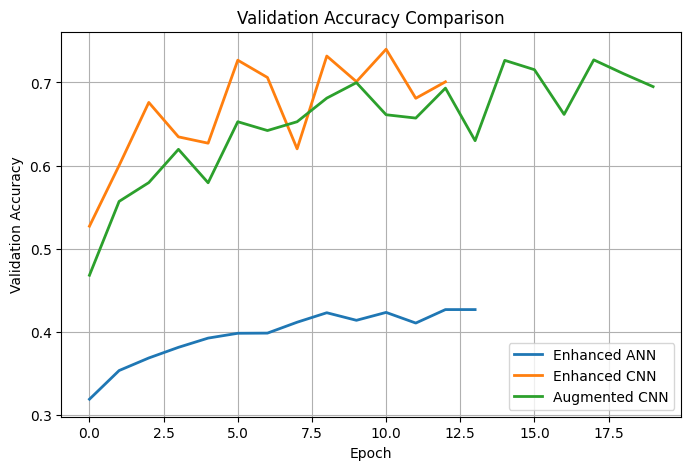

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    enhanced_ann_history.history['val_accuracy'],
    label='Enhanced ANN',
    linewidth=2
)

plt.plot(
    enhanced_cnn_history.history['val_accuracy'],
    label='Enhanced CNN',
    linewidth=2
)

plt.plot(
    augmented_cnn_history.history['val_accuracy'],
    label='Augmented CNN',
    linewidth=2
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

## Observation

The CNN models achieved higher validation accuracy than the ANN. The augmented CNN showed the most stable performance during training.

# Validation Loss Comparison

## Objective

Compare the validation loss of all enhanced models.

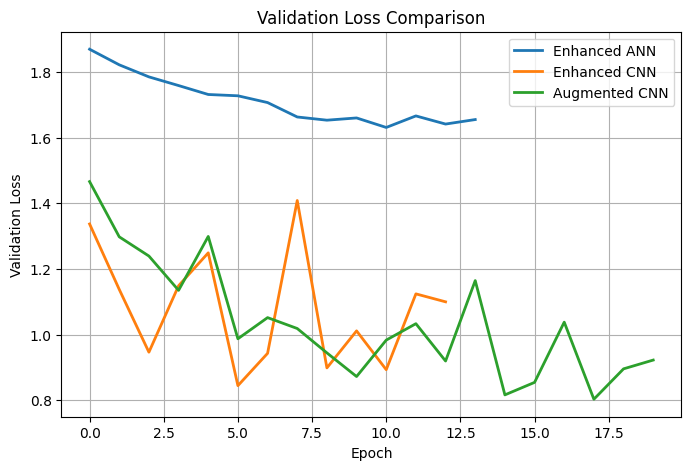

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    enhanced_ann_history.history['val_loss'],
    label='Enhanced ANN',
    linewidth=2
)

plt.plot(
    enhanced_cnn_history.history['val_loss'],
    label='Enhanced CNN',
    linewidth=2
)

plt.plot(
    augmented_cnn_history.history['val_loss'],
    label='Augmented CNN',
    linewidth=2
)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

## Observation

The validation loss decreases as the models learn better. The augmented CNN generally maintains a lower validation loss, indicating better generalization.

# Final Insights

- ANN provides a baseline for image classification.
- CNN performs better by learning spatial features.
- EarlyStopping helps reduce overfitting.
- Data augmentation improves generalization.
- The augmented CNN achieved the highest test accuracy.

# Conclusion

In this assignment, ANN and CNN models were developed for CIFAR-10 image classification. The models were enhanced using additional Dense layers, 20 training epochs, EarlyStopping, and data augmentation. The comparison showed that CNN-based models outperform ANN, while data augmentation further improves the model's accuracy and generalization.